In [2]:
!pip install qiskit
!pip install qutip.qip
!pip install qutip
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 42.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=33300ce1ffe25eed4f6d754903d5cccd153bb47334c7b799de453f39a9aba648
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c

In [3]:
import qutip as qt
import pylatexenc
import qiskit as qs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import seaborn as sns
from tqdm import tqdm
from scipy.linalg import expm, sinm, cosm
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
from qutip_qip.operations import *

In [ ]:
def Rxs(theta_a,theta_b):
    return tensor(rx(theta_a),qeye(16),rx(theta_b))

def cnots():
    cnot1=tensor(cnot(3,0,1),cnot(3,1,2))
    cnot2=tensor(cnot(3,0,2),cnot(3,2,0))
    return cnot2*cnot1

def rhoarhob(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,1/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return qt.Qobj(matrix,dims=[[2,2],[2,2]])
def rho(e, b,ea=1,ba=1):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sz=np.array([[1, 0], [0, -1]])
    # Constantes

    bb=b*ba
    eb=e*ea
    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sz
    H_B = -0.5 * eb * sz

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 1/(Za*Zb)

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    return qt.Qobj(np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab,dims=[[2,2],[2,2]])

def thetas(e,b,ea=1,ba=1):
  #parametro de correlação
  #parametros do sistema
  ea=1
  ba=1
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea*0.5)/Za

  p_b=np.exp(-bb*eb*0.5)/Zb

  #coeficiente

  a=1/(Za*Zb)

  theta_a=2*np.arctan(p_a)
  theta_b=2*np.arctan(p_b)

  return theta_a,theta_b

def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  ea=1
  ba=1
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb

  #coeficiente

  a=1/(Za*Zb)**1.5

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=abs(p_b-p_a)/(pp-pm)*0.5+0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pm))
  theta_b=2*np.arccos(np.sqrt(pp))

  return theta_a,theta_b,x

def entropy(rho):
    return qt.entropy_vn(rho)


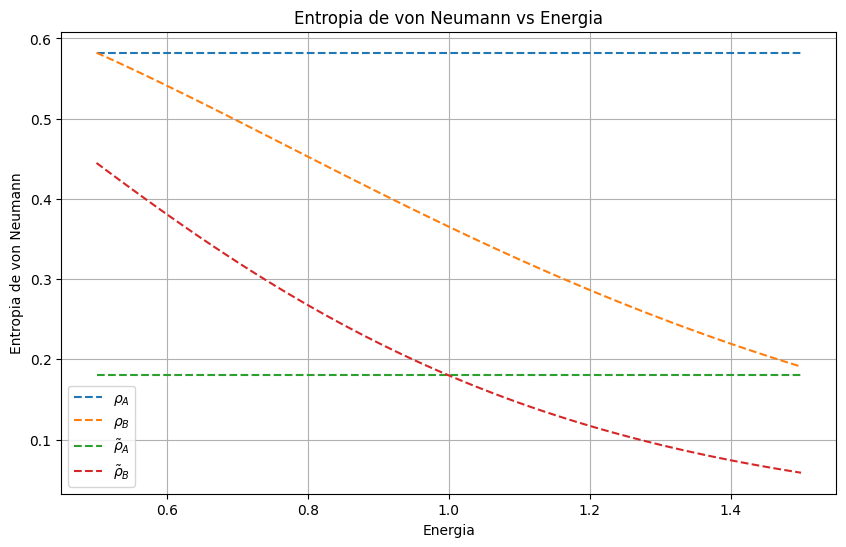

In [ ]:
ener=np.linspace(0.5,1.5,101)
#listas
entropies1=np.zeros(len(ener))
entropies2=np.zeros(len(ener))
entropies3=np.zeros(len(ener))
entropies4=np.zeros(len(ener))
#calculo da entropia
for i,e in enumerate(ener):
  entropies1[i]=entropy(ptrace(rho(e,2),[0]))
  entropies2[i]=entropy(ptrace(rho(e,2),[1]))
  entropies3[i]=entropy(ptrace(Qobj(rhoarhob(e,2),dims=[[2,2],[2,2]]),[0]))
  entropies4[i]=entropy(ptrace(Qobj(rhoarhob(e,2),dims=[[2,2],[2,2]]),[1]))
# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(ener, entropies1, '--', label='$\\rho_{A}$')
plt.plot(ener, entropies2, '--', label='$\\rho_{B}$')
plt.plot(ener, entropies3, '--', label='$\\tilde{\\rho}_{A}$')
plt.plot(ener, entropies4, '--', label='$\\tilde{\\rho}_{B}$')
plt.xlabel('Energia')
plt.ylabel('Entropia de von Neumann')
plt.title('Entropia de von Neumann vs Energia')
plt.legend()
plt.grid(True)
plt.show()


# valor negativo do $\rho_{-}$

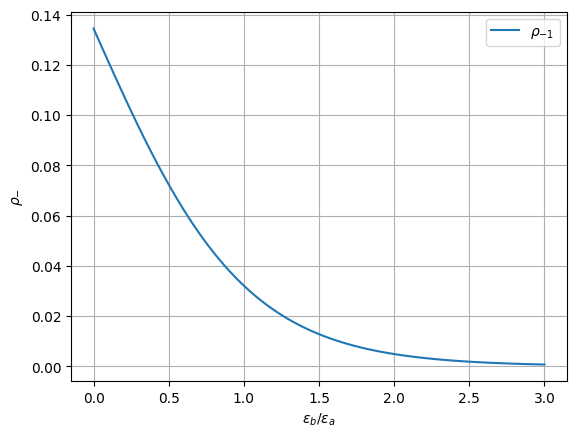

In [4]:
def pminus(e):
    ea=1
    ba=1
    bb=2*ba
    eb=e*ea
    #hamiltoniana do sitema
    H_A=-0.5*ea*qt.sigmaz()
    H_B=-0.5*eb*qt.sigmaz()
    #Função partição
    Za=((-ba*H_A).expm()).tr()
    Zb=((-bb*H_B).expm()).tr()
    #operador densidade
    p_a=np.exp(-ba*ea)/Za
    p_b=np.exp(-bb*eb)/Zb
    #parametro de correlação
    a=1/(Za*Zb)
    pm=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))
    return pm

def pminus1(e):
  ea=1
  ba=1
  bb=2*ba
  eb=e*ea
  #hamiltoniana do sitema
  H_A=-0.5*ea*qt.sigmaz()
  H_B=-0.5*eb*qt.sigmaz()
  #Função partição
  Za=((-ba*H_A).expm()).tr()
  Zb=((-bb*H_B).expm()).tr()
  #operador densidade
  p_a=np.exp(-ba*ea/2)/Za
  p_b=np.exp(-bb*eb/2)/Zb
  #parametro de correlação
  a=1/(Za*Zb)
  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))
  return pm

def pmminus(e):
  ea=1
  ba=1
  bb=2*ba
  eb=e*ea
  #hamiltoniana do sitema
  H_A=-0.5*ea*qt.sigmaz()
  H_B=-0.5*eb*qt.sigmaz()
  #Função partição
  Za=((-ba*H_A).expm()).tr()
  Zb=((-bb*H_B).expm()).tr()
  #operador densidade
  p_a=np.exp(-ba*ea/2)/Za
  p_b=np.exp(-bb*eb/2)/Zb
  #parametro de correlação
  a=1/(Za*Zb)
  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))
  return pm

def pab(e):
  ea=1
  ba=1
  bb=2*ba
  eb=e*ea
  #hamiltoniana do sitema
  H_A=-0.5*ea*qt.sigmaz()
  H_B=-0.5*eb*qt.sigmaz()
  #Função partição
  Za=((-ba*H_A).expm()).tr()
  Zb=((-bb*H_B).expm()).tr()
  #operador densidade
  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb
  return (p_a)*(p_b)
#calculo
e=np.linspace(0,3,101)
pm=[]
pp=[]
alphs=[]
p=[]
for i in e:
  pm.append(pminus(i))
  pp.append(pminus1(i))
  alphs.append(pmminus(i))
#plot
#plt.plot(e,pm,label='$\\rho_{-}$')
plt.plot(e,pp,label='$\\rho_{-1}$')
#plt.plot(e,p,label='$p_a p_b$')
#plt.plot(e,alphs,label='$\\rho_{--}$')
plt.xlabel('$\\epsilon_{b}/\\epsilon_{a}$')
plt.ylabel('$\\rho_{-}$')
#plt.ylim(-0.02,0.02)
plt.legend()
plt.grid(True)
plt.show()

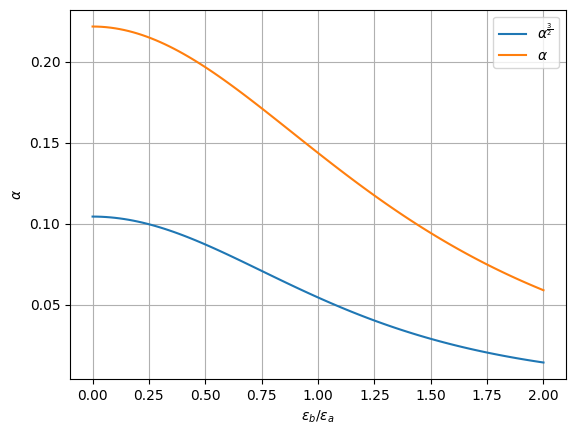

In [ ]:
def pminus(e):
    ea=1
    ba=1
    bb=2*ba
    eb=e*ea
    #hamiltoniana do sitema
    H_A=-0.5*ea*qt.sigmaz()
    H_B=-0.5*eb*qt.sigmaz()
    #Função partição
    Za=((-ba*H_A).expm()).tr()
    Zb=((-bb*H_B).expm()).tr()
    #operador densidade
    p_a=np.exp(-ba*ea)/Za
    p_b=np.exp(-bb*eb)/Zb
    #parametro de correlação
    a=(p_a*p_b)
    pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))
    return pm
def pplus(e):
    ea=1
    ba=1
    bb=2*ba
    eb=e*ea
    #hamiltoniana do sitema
    H_A=-0.5*ea*qt.sigmaz()
    H_B=-0.5*eb*qt.sigmaz()
    #Função partição
    Za=((-ba*H_A).expm()).tr()
    Zb=((-bb*H_B).expm()).tr()
    #operador densidade
    p_a=np.exp(-ba*ea)/Za
    p_b=np.exp(-bb*eb)/Zb
    #parametro de correlação
    a=1/(Za*Zb)**1.5
    return a
def a_z(e):
  ea=1
  ba=1
  bb=2*ba
  eb=e*ea
  #hamiltoniana do sitema
  H_A=-0.5*ea*qt.sigmaz()
  H_B=-0.5*eb*qt.sigmaz()
  #Função partição
  Za=((-ba*H_A).expm()).tr()
  Zb=((-bb*H_B).expm()).tr()
  #operador densidade
  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb
  #parametro de correlação
  a=1/(Za*Zb)
  return a
def pab(e):
  ea=1
  ba=1
  bb=2*ba
  eb=e*ea
  #hamiltoniana do sitema
  H_A=-0.5*ea*qt.sigmaz()
  H_B=-0.5*eb*qt.sigmaz()
  #Função partição
  Za=((-ba*H_A).expm()).tr()
  Zb=((-bb*H_B).expm()).tr()
  #operador densidade
  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb
  return (p_a)*(p_b)
#calculo
e=np.linspace(0,2,101)
pm=[]
pp=[]
alphs=[]
p=[]
for i in e:
  #pm.append(pminus(i))
  pp.append(pplus(i))
  alphs.append(a_z(i))
  p.append(pab(i))
#plot
#plt.plot(e,pm,label='$\\rho_{-}$')
plt.plot(e,pp,label='$\\alpha^{\\frac{3}{2}}$')
#plt.plot(e,p,label='$p_a p_b$')
plt.plot(e,alphs,label='$\\alpha$')
plt.xlabel('$\\epsilon_{b}/\\epsilon_{a}$')
plt.ylabel('$\\alpha$')
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-24-cf93518fcbed>:175: ComplexWarning: Casting complex values to real discards the imaginary part
  w_mean[1][j]=w1(e,2,l=0.6)
<ipython-input-24-cf93518fcbed>:176: ComplexWarning: Casting complex values to real discards the imaginary part
  w_mean[2][j]=w2(e,2,l=0.6)
<ipython-input-24-cf93518fcbed>:177: ComplexWarning: Casting complex values to real discards the imaginary part
  w_mean[3][j]=w3(e,2,l=0.6)


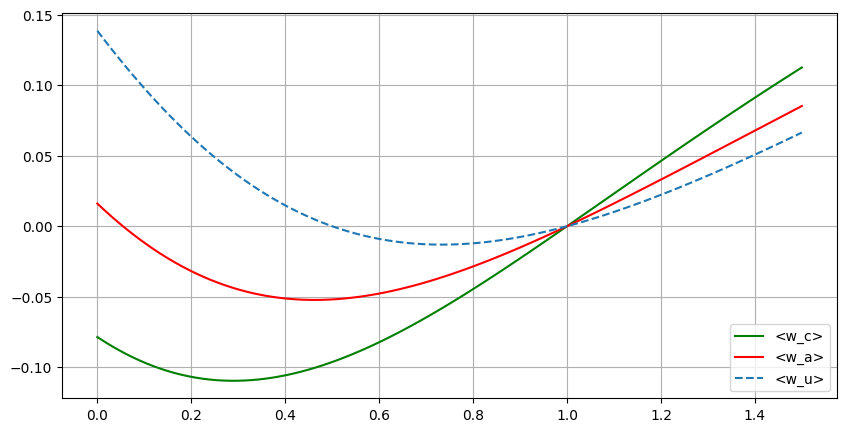

In [ ]:
def w1(e, b,ea=1,ba=1,l = 0.6):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sx=np.array([[1, 0], [0, -1]])
    # Constantes



    bb=b*ba
    eb=e*ea

    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sx
    H_B = -0.5 * eb * sx

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 1/(Zb*Za)

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    rho_ab=np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab

    #Partial_swap

    # Calculando a matriz evol
    cnot=np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])

    lamb=np.kron( idtt,[[1, 0], [0, 0]]) + np.kron( (idtt* np.sqrt(1 - l) + 1j * sy * np.sqrt(l)),[[0, 0], [0, 1]])

    evol = cnot@lamb@cnot

    # rho_f

    rho_ab_f=evol@rho_ab@evol.conj().T

    #hamiltoniana

    Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)

    return np.trace((rho_ab_f-rho_ab)@Hab)

def w2(e, b,ea=1,ba=1,l = 0.6):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sx=np.array([[1, 0], [0, -1]])
    # Constantes



    bb=b*ba
    eb=e*ea

    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sx
    H_B = -0.5 * eb * sx

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 1/(Zb*Za)**1.38

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    rho_ab=np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab

    #Partial_swap

    # Calculando a matriz evol
    cnot=np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])

    lamb=np.kron( idtt,[[1, 0], [0, 0]]) + np.kron( (idtt* np.sqrt(1 - l) + 1j * sy * np.sqrt(l)),[[0, 0], [0, 1]])

    evol = cnot@lamb@cnot

    # rho_f

    rho_ab_f=evol@rho_ab@evol.conj().T

    #hamiltoniana

    Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)

    return np.trace((rho_ab_f-rho_ab)@Hab)

def w3(e, b,ea=1,ba=1,l = 0.6):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sx=np.array([[1, 0], [0, -1]])
    # Constantes



    bb=b*ba
    eb=e*ea

    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sx
    H_B = -0.5 * eb * sx

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 0

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    rho_ab=np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab

    #Partial_swap

    # Calculando a matriz evol
    cnot=np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])

    lamb=np.kron( idtt,[[1, 0], [0, 0]]) + np.kron( (idtt* np.sqrt(1 - l) + 1j * sy * np.sqrt(l)),[[0, 0], [0, 1]])

    evol = cnot@lamb@cnot

    # rho_f

    rho_ab_f=evol@rho_ab@evol.conj().T

    #hamiltoniana

    Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)

    return np.trace((rho_ab_f-rho_ab)@Hab)

#vetores
ea=np.linspace(0,1.5,101)
w_mean=np.zeros((6,101))
#ploot

for j,e in enumerate(ea):
  w_mean[1][j]=w1(e,2,l=0.6)
  w_mean[2][j]=w2(e,2,l=0.6)
  w_mean[3][j]=w3(e,2,l=0.6)
plt.figure(figsize=(10, 5))
plt.plot(ea, w_mean[1],label='<w_c>',color='green')
plt.plot(ea, w_mean[2],label='<w_a>',color='red')
plt.plot(ea, w_mean[3],'--',label='<w_u>')
plt.grid()
plt.legend()
plt.show()

In [ ]:
def rhoarhob_a(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,1/(Z_a*Z_b)**1.5

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return matrix

def rhoarhob_u(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,0

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return matrix

def rhoarhob_c(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,1/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return matrix

def rho(e, b,ea=1,ba=1):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sz=np.array([[1, 0], [0, -1]])
    # Constantes

    bb=b*ba
    eb=e*ea
    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sz
    H_B = -0.5 * eb * sz

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 1/(Za*Zb)

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    return qt.Qobj(np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab,dims=[[2,2],[2,2]])

def w1(rho_ab,e,l = 0.6):
    ea=1
    eb=e*ea
    #Partial_swap
    idtt= np.eye(2)
    sy = np.array([[0, -1j], [1j, 0]])
    sz=np.array([[1, 0], [0, -1]])
    #hamiltoniana
    H_A = -0.5 * ea * sz
    H_B = -0.5 * eb * sz

    # Calculando a matriz evol
    cnot=np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])

    lamb=np.kron( idtt,[[1, 0], [0, 0]]) + np.kron( (idtt* np.sqrt(1 - l) + 1j * sy * np.sqrt(l)),[[0, 0], [0, 1]])

    evol = cnot@lamb@cnot

    # rho_f

    rho_ab_f=evol@rho_ab@evol.conj().T

    #hamiltoniana

    Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)
    return np.trace((rho_ab_f-rho_ab)@Hab)



<ipython-input-8-a68f5d408dfc>:7: ComplexWarning: Casting complex values to real discards the imaginary part
  w_mean[1][j]=w1(rhoarhob_u(e),e,l=0.6)
<ipython-input-8-a68f5d408dfc>:8: ComplexWarning: Casting complex values to real discards the imaginary part
  w_mean[2][j]=w1(rhoarhob_a(e),e,l=0.6)
<ipython-input-8-a68f5d408dfc>:9: ComplexWarning: Casting complex values to real discards the imaginary part
  w_mean[3][j]=w1(rhoarhob_c(e),e,l=0.6)


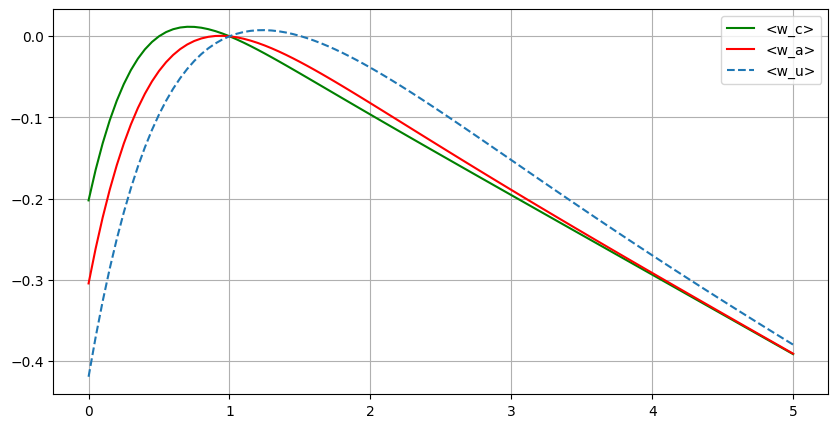

In [ ]:
#vetores
ea=np.linspace(0,5,101)
w_mean=np.zeros((6,101))
#ploot

for j,e in enumerate(ea):
  w_mean[1][j]=w1(rhoarhob_u(e),e,l=0.6)
  w_mean[2][j]=w1(rhoarhob_a(e),e,l=0.6)
  w_mean[3][j]=w1(rhoarhob_c(e),e,l=0.6)
plt.figure(figsize=(10, 5))
plt.plot(ea, w_mean[1],label='<w_c>',color='green')
plt.plot(ea, w_mean[2],label='<w_a>',color='red')
plt.plot(ea, w_mean[3],'--',label='<w_u>')
plt.grid()
plt.legend()
plt.show()

# Entropia de Von Neumann

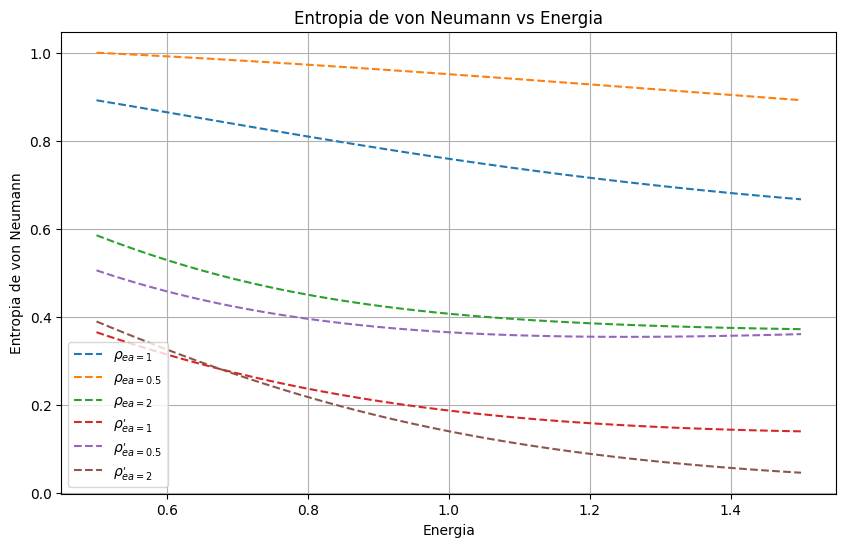

In [ ]:
ener=np.linspace(0.5,1.5,101)
#listas
entropies=np.zeros((6,len(ener)))

#calculo da entropia
for i,e in enumerate(ener):
  entropies[0][i]=qt.entropy_vn(rho(e,2,ea=1))
  entropies[1][i]=qt.entropy_vn(rho(e,2,ea=0.5))
  entropies[2][i]=qt.entropy_vn(rho(e,2,ea=2))
  entropies[3][i]=qt.entropy_vn(Qobj(rhoarhob(e,2,1),dims=[[2,2],[2,2]]))
  entropies[4][i]=qt.entropy_vn(Qobj(rhoarhob(e,2,0.5),dims=[[2,2],[2,2]]))
  entropies[5][i]=qt.entropy_vn(Qobj(rhoarhob(e,2,2),dims=[[2,2],[2,2]]))
# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(ener, entropies[0], '--', label='$\\rho_{ea=1}$')
plt.plot(ener, entropies[1], '--', label='$\\rho_{ea=0.5}$')
plt.plot(ener, entropies[2], '--', label='$\\rho_{ea=2}$')
plt.plot(ener, entropies[3], '--', label='$\\rho^{,}_{ea=1}$')
plt.plot(ener, entropies[4], '--', label='$\\rho^{,}_{ea=0.5}$')
plt.plot(ener, entropies[5], '--', label='$\\rho^{,}_{ea=2}$')
plt.xlabel('Energia')
plt.ylabel('Entropia de von Neumann')
plt.title('Entropia de von Neumann vs Energia')
plt.legend()
plt.grid(True)
plt.show()

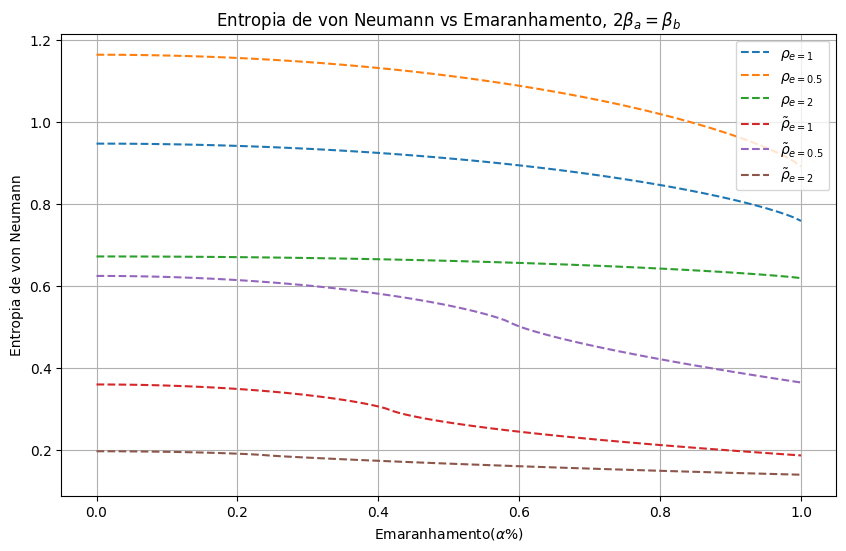

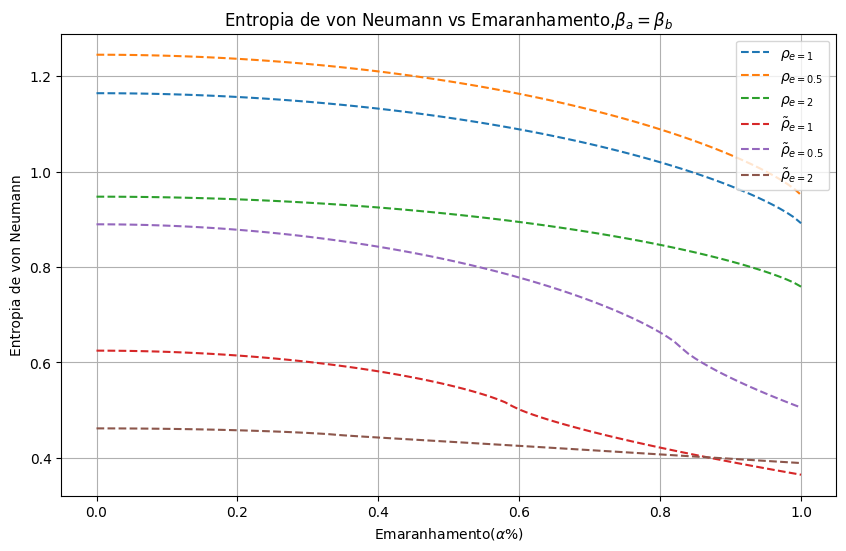

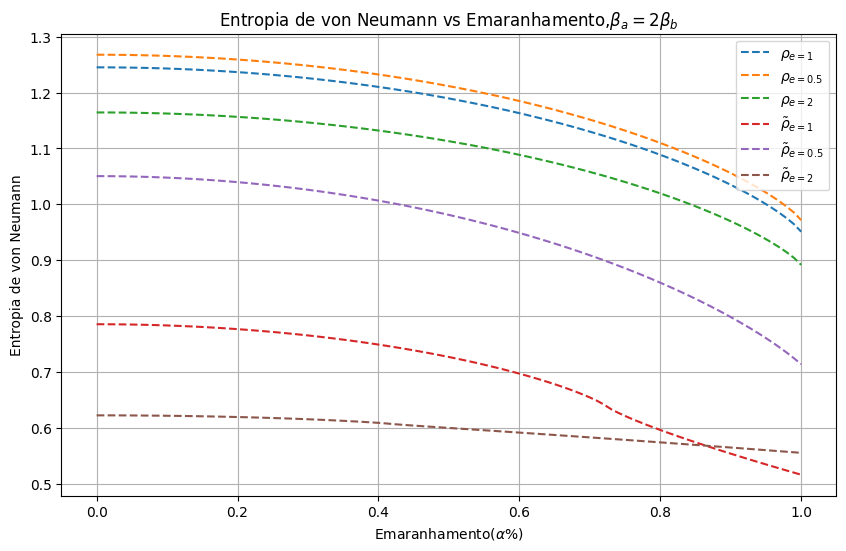

In [ ]:
def rhoarhob_a(epsilon_b,beta_a=1,fator_a=1,alpha=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,fator_a/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return qt.Qobj(matrix,dims=[[2,2],[2,2]])

def rho_a(e, b,f_a,ea=1,ba=1,):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sz=np.array([[1, 0], [0, -1]])
    # Constantes

    bb=b*ba
    eb=e*ea
    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sz
    H_B = -0.5 * eb * sz

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = f_a/(Za*Zb)

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    return qt.Qobj(np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab,dims=[[2,2],[2,2]])


alphs=np.linspace(0,1,101)
#listas
entropies=np.zeros((6,len(ener)))

#calculo da entropia
for i,a in enumerate(alphs):
  entropies[0][i]=qt.entropy_vn(rho_a(1,2,a))
  entropies[1][i]=qt.entropy_vn(rho_a(0.5,2,a))
  entropies[2][i]=qt.entropy_vn(rho_a(2,2,a))
  entropies[3][i]=qt.entropy_vn(rhoarhob_a(1,2,a))
  entropies[4][i]=qt.entropy_vn(rhoarhob_a(0.5,2,a))
  entropies[5][i]=qt.entropy_vn(rhoarhob_a(2,2,a))
# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(alphs, entropies[0], '--', label='$\\rho_{e=1}$')
plt.plot(alphs, entropies[1], '--', label='$\\rho_{e=0.5}$')
plt.plot(alphs, entropies[2], '--', label='$\\rho_{e=2}$')
plt.plot(alphs, entropies[3], '--', label='$\\tilde{\\rho}_{e=1}$')
plt.plot(alphs, entropies[4], '--', label='$\\tilde{\\rho}_{e=0.5}$')
plt.plot(alphs, entropies[5], '--', label='$\\tilde{\\rho}_{e=2}$')
plt.xlabel('Emaranhamento($\\alpha$%)')
plt.ylabel('Entropia de von Neumann')
plt.title('Entropia de von Neumann vs Emaranhamento, $2\\beta_a=\\beta_b$')
plt.legend()
plt.grid(True)
plt.show()

#listas
entropies=np.zeros((6,len(ener)))

#calculo da entropia
for i,a in enumerate(alphs):
  entropies[0][i]=qt.entropy_vn(rho_a(1,1,a))
  entropies[1][i]=qt.entropy_vn(rho_a(0.5,1,a))
  entropies[2][i]=qt.entropy_vn(rho_a(2,1,a))
  entropies[3][i]=qt.entropy_vn(rhoarhob_a(1,1,a))
  entropies[4][i]=qt.entropy_vn(rhoarhob_a(0.5,1,a))
  entropies[5][i]=qt.entropy_vn(rhoarhob_a(2,1,a))
# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(alphs, entropies[0], '--', label='$\\rho_{e=1}$')
plt.plot(alphs, entropies[1], '--', label='$\\rho_{e=0.5}$')
plt.plot(alphs, entropies[2], '--', label='$\\rho_{e=2}$')
plt.plot(alphs, entropies[3], '--', label='$\\tilde{\\rho}_{e=1}$')
plt.plot(alphs, entropies[4], '--', label='$\\tilde{\\rho}_{e=0.5}$')
plt.plot(alphs, entropies[5], '--', label='$\\tilde{\\rho}_{e=2}$')
plt.xlabel('Emaranhamento($\\alpha$%)')
plt.ylabel('Entropia de von Neumann')
plt.title('Entropia de von Neumann vs Emaranhamento,$\\beta_a=\\beta_b$')
plt.legend()
plt.grid(True)
plt.show()


#listas
entropies=np.zeros((6,len(ener)))

#calculo da entropia
for i,a in enumerate(alphs):
  entropies[0][i]=qt.entropy_vn(rho_a(1,0.5,a))
  entropies[1][i]=qt.entropy_vn(rho_a(0.5,0.5,a))
  entropies[2][i]=qt.entropy_vn(rho_a(2,0.5,a))
  entropies[3][i]=qt.entropy_vn(rhoarhob_a(1,0.5,a))
  entropies[4][i]=qt.entropy_vn(rhoarhob_a(0.5,0.5,a))
  entropies[5][i]=qt.entropy_vn(rhoarhob_a(2,0.5,a))
# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(alphs, entropies[0], '--', label='$\\rho_{e=1}$')
plt.plot(alphs, entropies[1], '--', label='$\\rho_{e=0.5}$')
plt.plot(alphs, entropies[2], '--', label='$\\rho_{e=2}$')
plt.plot(alphs, entropies[3], '--', label='$\\tilde{\\rho}_{e=1}$')
plt.plot(alphs, entropies[4], '--', label='$\\tilde{\\rho}_{e=0.5}$')
plt.plot(alphs, entropies[5], '--', label='$\\tilde{\\rho}_{e=2}$')
plt.xlabel('Emaranhamento($\\alpha$%)')
plt.ylabel('Entropia de von Neumann')
plt.title('Entropia de von Neumann vs Emaranhamento,$\\beta_a=2\\beta_b$')
plt.legend()
plt.grid(True)
plt.show()

# Circuito de emaranhamento


In [ ]:
def control_target(control,target,num_bits,U):
  # Define projectors for the control qubit
  P0 = qt.basis(2, 0) * qt.basis(2, 0).dag()  # Projector onto the |0> state
  P1 = qt.basis(2, 1) * qt.basis(2, 1).dag()  # Projector onto the |1> state
  #criando qobj
  C0 =qt.Qobj(1)
  C1 =qt.Qobj(1)
  #criando gate com controle e alvo
  for i in range(num_bits):
    #criando operação no alvo
    if target==i:

      C0=tensor(C0,qeye(2))
      C1=tensor(C1,U)
    #escolhendo o controle
    elif control==i:

      C0=tensor(C0,P0)
      C1=tensor(C1,P1)

    else:

      C0=tensor(C0,qeye(2))
      C1=tensor(C1,qeye(2))
  return np.array((C0+C1).full())

def u_plus(x):
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 + term2
    return u_minus


def u_minus(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return u_minus
def cnot_gate(control, target, num_qubits):
    return np.array(cnot(N=num_qubits,control=control, target=target).full())

def cnots_n(n_qubits):
    #gerando o tamanho dos dois cnots
    inteiro=int(n_qubits/2)
    cn_quan=Qobj(qeye(2**n_qubits),dims=(cnot(n_qubits,0,1).dims))
    #gerando cnot generalizado
    for i in range(1,inteiro):

      flag=tensor(cnot(inteiro,0,i),cnot(inteiro,inteiro-1,inteiro-(i+1)))
      cn_quan=cn_quan*flag
    return cn_quan

def box_correlation(num_qubits,control,target,x):

    circuit =cnot_gate(control, target, num_qubits)@control_target(target,control,num_qubits,u_minus(x))@cnot_gate(control, target, num_qubits)

    return circuit

def box_par_swap(num_qubits,control,target,x):

    circuit =cnot_gate(control, target, num_qubits)@control_target(target,control,num_qubits,u_plus(x))@cnot_gate(control, target, num_qubits)

    return circuit
def boxs_correlation(num_qubits,x):
    #gerando a matriz identidade para gerar os circuitos
    result=Qobj(qeye(2**num_qubits),dims=(cnot(num_qubits,0,3).dims))
    inteiro=int(num_qubits/2)
    #multiplicando as portas lógicas
    for i in range(inteiro):
      result=result*Qobj(box_correlation(num_qubits,(inteiro-(i+1)),(inteiro+i),x),dims=(cnot(num_qubits,0,1).dims))
    return result

def boxs_par_swap(num_qubits):
    #gerando a matriz identidade para gerar os circuitos
    result=Qobj(qeye(2**num_qubits),dims=(cnot(num_qubits,0,1).dims))
    inteiro=int(num_qubits/2)
    #multiplicando as portas lógicas
    for i in range(inteiro):
      result=Qobj(box_par_swap(num_qubits,(inteiro-(i+1)),(inteiro+i),0.6),dims=(cnot(num_qubits,0,1).dims))*result
    return result

def hamiltoniana(eb,ea=1,num_qubits=4):
  #gerando a matriz identidade para gerar os circuitos
  resultfi=Qobj(qeye(2**(num_qubits-2)),dims=(cnot(num_qubits-2,0,1).dims))
  inteiro=int((num_qubits)/2)
  #gerando o hamiltoniano
  for i in range(1,num_qubits-1):
    result1=Qobj(1)
    result2=Qobj(1)
    for j in range(1,num_qubits-1):
      if i==j and i<inteiro:
        result1=tensor(result1,-ea*qt.sigmaz()/2)
        result2=tensor(result2,qeye(2))
      elif i==j and i>=inteiro:
        result2=tensor(result2,-eb*qt.sigmaz()/2)
        result1=tensor(result1,qeye(2))
      else:
        result1=tensor(result1,qeye(2))
        result2=tensor(result2,qeye(2))
    resultfi=resultfi+Qobj(result1+result2,dims=cnot(num_qubits-2,0,1).dims)
  return resultfi

def Rxs(theta_a,theta_b,N):
    #gerando portas de rotação que representarão um estado termico
    return Qobj(tensor(rx(theta_a),qeye(2**(N-2)),rx(theta_b)),dims=cnot(N,0,1).dims)

def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb
  #coeficiente

  a=1/(Za*Zb)**1.5

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x


/usr/local/lib/python3.10/dist-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


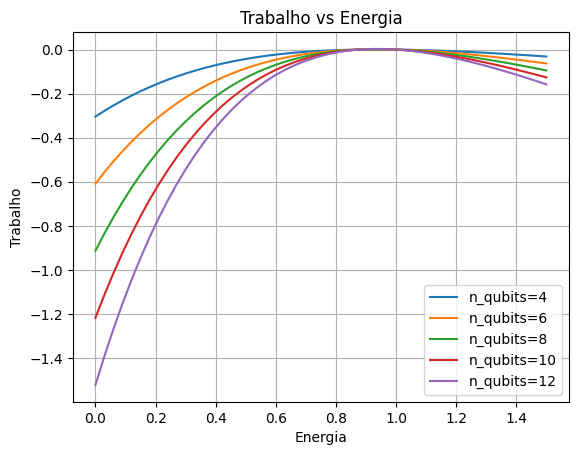

In [ ]:
ener=np.linspace(0,1.5,51)
for i in range(4,13,2):
  w_mean=np.zeros(len(ener),dtype=complex)
  box1=cnots_n(i)
  box2=boxs_par_swap(i)
  for j,e in enumerate(ener):
    dimension=cnot(i,0,1).dims
    rho0=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
    # gerando estado
    theta_a,theta_b,x=thetas_c(e,2)
    trace_ind=np.linspace(1,i-2,i-2,dtype=int)
    rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0
    #calculando rho final
    rho0=rho_therma_corr1*rho_therma_corr1.dag()
    rho_therma_corr1=box2*rho_therma_corr1
    rhof=rho_therma_corr1*rho_therma_corr1.dag()
    #calculo do trabalho
    w_mean[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())
  plt.plot(ener,w_mean,label="n_qubits=%i"%i)

plt.xlabel('Energia')
plt.ylabel('Trabalho')
plt.legend()
plt.title('Trabalho vs Energia')
plt.grid(True)
plt.show()

In [ ]:
i=6
e=0.1
dimension=cnot(i,0,1).dims
rho0=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
# gerando estado
theta_a,theta_b,x=thetas_c(e,2)
print(theta_a,theta_b,x)
trace_ind=np.linspace(1,i-2,i-2,dtype=int)
box1=cnots_n(i)
rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0
trace_ind=np.linspace(1,i-2,i-2,dtype=int)
print(trace_ind)
rho0=rho_therma_corr1*rho_therma_corr1.dag()
#calculando rho final
box2=boxs_par_swap(i)
rho_therma_corr1=box2*rho_therma_corr1
rhof=rho_therma_corr1*rho_therma_corr1.dag()
print(((ptrace(rhof,[2,3])-ptrace(rho0,[2,3]))*hamiltoniana(e,1,4)).tr())

1.68028810601501 2.4186019410842508 0.8812396846622125
[1 2 3 4]
(-0.22323801509131436+0j)


In [ ]:
ener=np.linspace(0.5,1.5,101)
#listas
entropies=np.zeros((6,len(ener)))

#calculo do trabalho
for i,e in enumerate(ener):
  entropies[0][i]=qt.entropy_vn(rho_therma_corr)
plt.figure(figsize=(10, 6))
plt.plot(ener, entropies[0], '--', label='$\\rho_{e=1}$')
plt.xlabel('Emaranhamento($\\alpha$%)')
plt.ylabel('Entropia de von Neumann')
plt.title('Entropia de von Neumann vs Emaranhamento,$\\beta_a=2\\beta_b$')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'rho_therma_corr' is not defined

In [ ]:
#gerando estado gibbs
rho0=Qobj(qt.basis(64,0),dims=[[2,2,2,2,2,2],[1]])
theta_a,theta_b=np.pi/2,np.pi/4

# gerando estado
rho_therma_corr1=boxs_correlation(6)*cnots_n(6)*Rxs(theta_a,theta_b,6)*rho0
rho_therma_corr1=rho_therma_corr1*rho_therma_corr1.dag()
#plot da matriz densidade
plt.imshow(np.array(ptrace(rho_therma_corr1,[2,3]).full(),dtype=float), cmap='viridis', interpolation='nearest')
plt.colorbar(label='Valor')
plt.show()

#gerando estado gibbs
rho0=Qobj(qt.basis(64,0),dims=[[2,2,2,2,2,2],[1]])
theta_a,theta_b=np.pi/2,np.pi/4

# gerando estado
rho_therma=Qobj(box_correlation(6,2,3,0.5),dims=[[2,2,2,2,2,2],[2,2,2,2,2,2]])*Qobj(box_correlation(6,1,4,0.5),dims=[[2,2,2,2,2,2],[2,2,2,2,2,2]])*cnots()*Rxs(theta_a,theta_b,6)*rho0

rho_therma_corr2=rho_therma*rho_therma.dag()
#plot da matriz densidade
plt.imshow(np.array(ptrace(rho_therma_corr2,[2,3]).full(),dtype=float), cmap='viridis', interpolation='nearest')
plt.colorbar(label='Valor')
plt.show()


In [ ]:
trace_ind=np.linspace(1,i,i,dtype=int)
print(trace_ind)

# evolução temporal

Primeiramente resolveremos um exemplo

In [ ]:
H = 2 * np.pi * 0.1 * qt.sigmax()
psi0 = qt.basis(2, 0)
times = np.linspace(0.0, 10.0, 21)
result = qt.mesolve(H, psi0, times, [], [qt.sigmaz()])

Temos que o operador de evolução temporal é representado como

$U(t)_{\tau}=exp\left(\frac{-ijt}{2}\sum_{j} \sigma_{j}^{A} \otimes \sigma_{j}^{B}\right)$

In [ ]:
def cnots():
    cnot1=tensor(cnot(3,0,1),cnot(3,2,1))
    cnot2=tensor(cnot(3,0,2),cnot(3,2,0))
    return Qobj(cnot1*cnot2)
#gerando a matriz densidade

rho0=Qobj(qt.basis(64,0),dims=[[2,2,2,2,2,2],[1]])
theta_a,theta_b=thetas(2,2)
# gerando estado
rho_therma=cnots()*Rxs(theta_a,theta_b,6)*rho0

#matriz densidade
rho_therma=rho_therma*rho_therma.dag()


print(ptrace(rho_therma,[2,3]))
times = np.linspace(0.0,3.14 , 21)
# interação de heinseberg

u=tensor(qt.sigmax(),qt.sigmax(),qt.sigmax(),qt.sigmax())+tensor(qt.sigmay(),qt.sigmay(),qt.sigmay(),qt.sigmay())+tensor(qt.sigmaz(),qt.sigmaz(),qt.sigmaz(),qt.sigmaz())
u=tensor(qt.sigmax(),qt.sigmax(),qt.sigmax(),qt.sigmax())+tensor(qt.sigmay(),qt.sigmay(),qt.sigmay(),qt.sigmay())+tensor(qt.sigmaz(),qt.sigmaz(),qt.sigmaz(),qt.sigmaz())
H=tensor(qt.sigmaz(),Qobj(qeye(8),dims=[[2,2,2],[2,2,2]]))+tensor(qeye(2),qt.sigmaz(),Qobj(qeye(4),dims=[[2,2],[2,2]]))+tensor(Qobj(qeye(4),dims=[[2,2],[2,2]]),qt.sigmaz(),qeye(2))+tensor(Qobj(qeye(8),dims=[[2,2,2],[2,2,2]]),qt.sigmaz())
#evolutação temporal

resolve2=qt.mesolve(u*0.5,ptrace(rho_therma,[1,2,3,4]),times,[]).states


# Configuração da animação
fig, ax = plt.subplots()
ims = []  # Lista para armazenar os frames

# Loop para gerar os frames
for rho in resolve2:
    im = ax.matshow(np.array(ptrace(rho, [1, 2]).full(), dtype=float), cmap='viridis', interpolation='nearest')
    ims.append([im])  # Adiciona o frame à lista

# Criação da animação
ani = animation.ArtistAnimation(fig, ims, interval=500, blit=True, repeat_delay=1000)  # 500ms por frame

# Exibição da animação
plt.colorbar(im, label='Valor')
plt.title('Thermal Correlation')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
for i in range(21):
  plt.figure(figsize=(8, 6))
  plt.matshow(np.array(ptrace(resolve2[i],[1,2]).full(),dtype=float), cmap='viridis', interpolation='nearest')
  plt.colorbar(label='Valor')
  plt.title('therma correlation')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()